In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

Data shape: (1797, 64)
Images shape: (1797, 8, 8)
Target classes: [0 1 2 3 4 5 6 7 8 9]


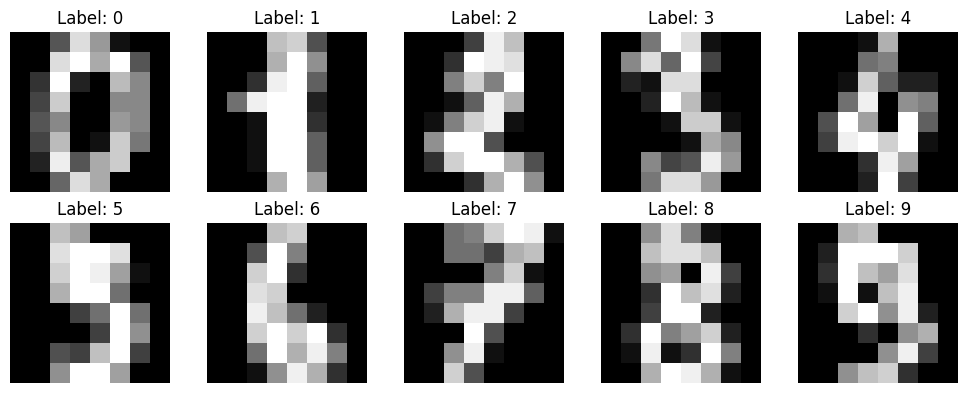

In [2]:
# --- Dataset Selection and Preprocessing ---
# Dataset: sklearn's digits dataset — 1,797 images of handwritten digits (0-9),
# each represented as an 8x8 grayscale image (64 pixels total)

digits = load_digits()

print("Data shape:", digits.data.shape)
print("Images shape:", digits.images.shape)
print("Target classes:", np.unique(digits.target))

# Visualize a few sample images to confirm the data loaded correctly
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [3]:
# Resizing: not needed here — all images are already a uniform 8x8 size,
# unlike a typical photo dataset where images come in varying dimensions
print("All images are uniform size:", digits.images.shape[1:])

# Normalizing pixel values: scale from the original 0-16 range down to 0-1
print("Pixel value range before normalization:", digits.data.min(), "to", digits.data.max())

X = digits.data / 16.0  # normalize to 0-1
y = digits.target

print("Pixel value range after normalization:", X.min(), "to", X.max())

All images are uniform size: (8, 8)
Pixel value range before normalization: 0.0 to 16.0
Pixel value range after normalization: 0.0 to 1.0


In [4]:
# Splitting into train/test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1437, 64)
Testing set shape: (360, 64)


### Preprocessing Notes

This dataset's images are already a uniform 8×8 size, so no resizing was necessary — unlike typical
photo datasets sourced from varied cameras/sources. Pixel values were normalized from their original
0–16 range down to 0–1, which helps models that are sensitive to feature scale (though Random Forest
itself is scale-invariant, this is still good practice and matters for the SVM comparison later). The
data was split 80/20 into train/test sets, stratified by digit class to ensure proportional
representation of all 10 digits in both sets

In [5]:
# --- Model Training: Random Forest Classifier ---

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

# Perform Grid Search to find the best parameters
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Print the best parameters and get the best model
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

best_rf_model = grid_search.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy: 0.975633952768099


In [6]:
# Train the Random Forest model on the training data
best_rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [7]:
# --- Model Evaluation ---

# Make predictions on the test set using the best model
y_pred_rf = best_rf_model.predict(X_test)

# Evaluate using accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='macro')
recall = recall_score(y_test, y_pred_rf, average='macro')
f1 = f1_score(y_test, y_pred_rf, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (macro avg): {precision:.4f}")
print(f"Recall (macro avg): {recall:.4f}")
print(f"F1-score (macro avg): {f1:.4f}")

Accuracy: 0.9639
Precision (macro avg): 0.9647
Recall (macro avg): 0.9636
F1-score (macro avg): 0.9635


In [8]:
# Confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred_rf)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.90      0.97      0.93        36
           2       1.00      1.00      1.00        35
           3       0.97      0.97      0.97        37
           4       0.97      0.97      0.97        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.92      1.00      0.96        36
           8       0.94      0.86      0.90        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



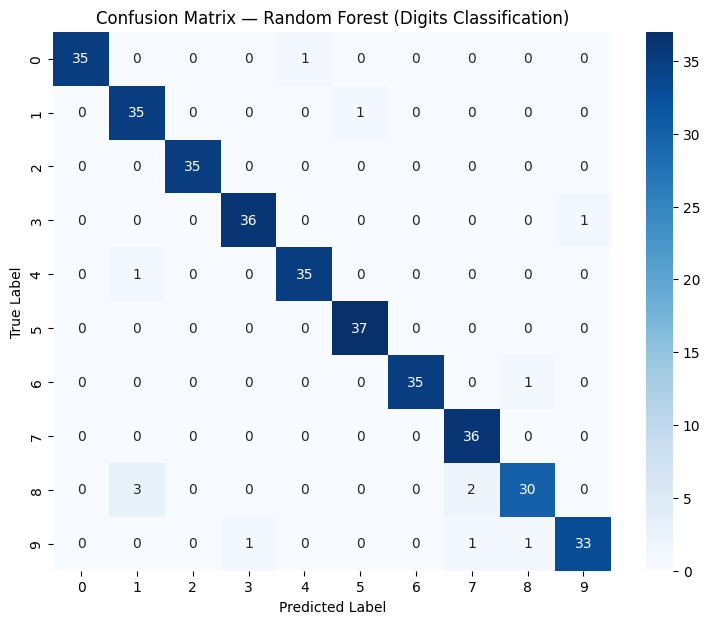

In [9]:
# Visualize the confusion matrix
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix — Random Forest (Digits Classification)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [10]:
# --- Feature Importance Visualization ---

# Get feature importances from the best model
importances = best_rf_model.feature_importances_
print("Feature importances shape:", importances.shape)  # should be (64,) — one per pixel

Feature importances shape: (64,)


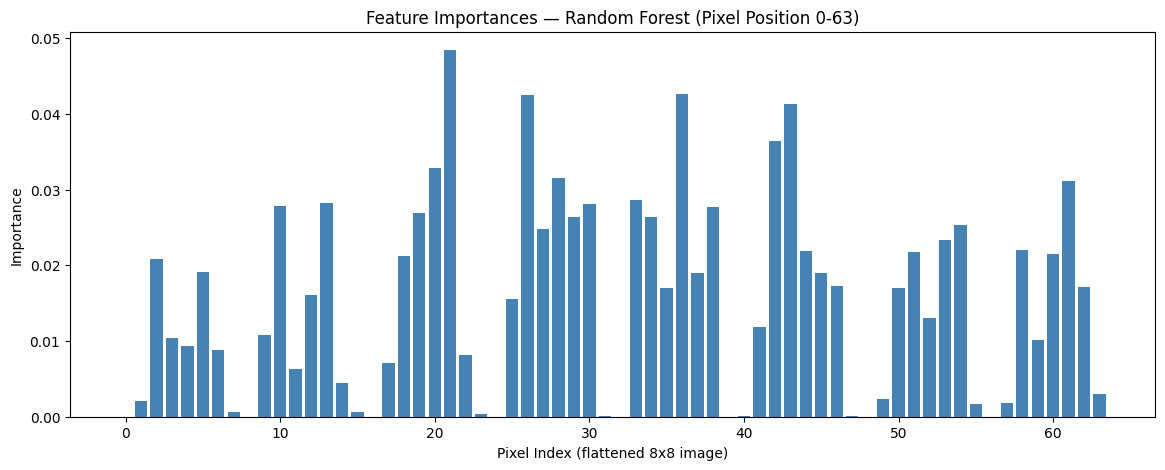

In [11]:
# Bar plot of feature importances (all 64 pixels, in order)
plt.figure(figsize=(14, 5))
plt.bar(range(64), importances, color='steelblue')
plt.title('Feature Importances — Random Forest (Pixel Position 0-63)')
plt.xlabel('Pixel Index (flattened 8x8 image)')
plt.ylabel('Importance')
plt.show()

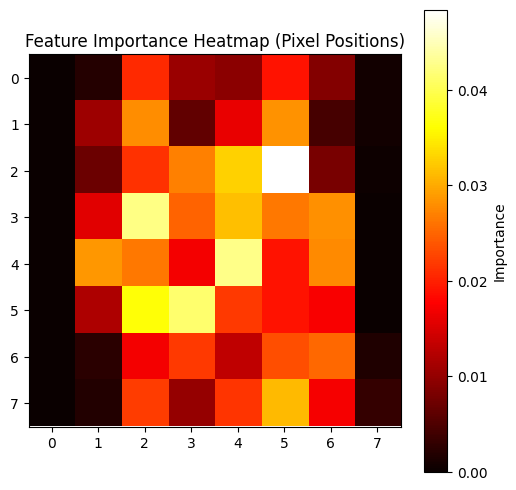

In [12]:
# Bonus: reshape importances back into an 8x8 grid to visualize spatially
importance_image = importances.reshape(8, 8)

plt.figure(figsize=(6, 6))
plt.imshow(importance_image, cmap='hot', interpolation='nearest')
plt.title('Feature Importance Heatmap (Pixel Positions)')
plt.colorbar(label='Importance')
plt.xticks(range(8))
plt.yticks(range(8))
plt.show()

### Feature Importance Insights

The feature importance heatmap shows that pixels near the center of the 8x8 grid contribute far
more to classification decisions than pixels near the corners or edges. This makes intuitive sense —
the actual pen strokes of handwritten digits are concentrated in the central region of each image,
while corner pixels are almost always blank background regardless of which digit was drawn, providing
little information to distinguish between classes

In [13]:
# --- Prediction on New Images ---

def predict_digit(image_array, model, scale_max=16.0):
    """
    Predicts the digit class for a new image.

    Parameters:
        image_array: a 2D array (8x8) or already-flattened 1D array (64,) representing the image
        model: a trained classifier (e.g., best_rf_model)
        scale_max: the maximum pixel value used for normalization (16.0 for this dataset)

    Returns:
        predicted_class: the predicted digit (0-9)
    """
    # Flatten if given as 2D
    if image_array.ndim == 2:
        image_array = image_array.flatten()

    # Apply the SAME preprocessing used during training: normalize to 0-1
    image_normalized = image_array / scale_max

    # Reshape into the (1, 64) format sklearn expects for a single prediction
    image_reshaped = image_normalized.reshape(1, -1)

    predicted_class = model.predict(image_reshaped)[0]
    return predicted_class

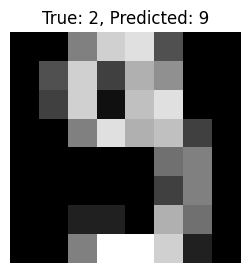

True label: 2
Predicted label: 9


In [14]:
# Test the function with a new image

test_index = 7
sample_image = digits.images[len(X_train) + test_index]  # approximate way to grab an unseen image
true_label = y_test[test_index]

# Use the original (un-normalized) image, exactly as the function expects
sample_image_raw = sample_image  # still in 0-16 range, as the function will normalize internally

predicted = predict_digit(sample_image_raw, best_rf_model)

plt.figure(figsize=(3, 3))
plt.imshow(sample_image_raw, cmap='gray')
plt.title(f"True: {true_label}, Predicted: {predicted}")
plt.axis('off')
plt.show()

print(f"True label: {true_label}")
print(f"Predicted label: {predicted}")

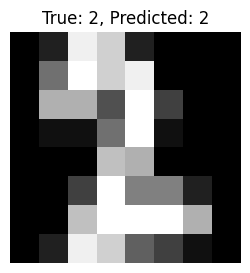

True label: 2
Predicted label: 2


In [15]:
# More rigorous version: pick directly from X_test/y_test, then reshape back to 8x8 for display
test_index = 7
sample_flat = X_test[test_index] * 16.0  # undo normalization to get back to raw 0-16 pixel values
sample_image_2d = sample_flat.reshape(8, 8)
true_label = y_test[test_index]

predicted = predict_digit(sample_image_2d, best_rf_model)

plt.figure(figsize=(3, 3))
plt.imshow(sample_image_2d, cmap='gray')
plt.title(f"True: {true_label}, Predicted: {predicted}")
plt.axis('off')
plt.show()

print(f"True label: {true_label}")
print(f"Predicted label: {predicted}")

In [16]:
# --- Bonus: Comparing with SVM ---

# SVMs are sensitive to feature scale, so standardization (not just 0-1 normalization)
# often helps performance — we'll use StandardScaler here for a fair comparison
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define a parameter grid for SVM, following the same GridSearchCV process as Random Forest
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm = SVC(random_state=42)

svm_grid_search = GridSearchCV(
    svm,
    svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

svm_grid_search.fit(X_train_scaled, y_train)

print("Best SVM parameters found:", svm_grid_search.best_params_)
print("Best SVM cross-validation accuracy:", svm_grid_search.best_score_)

best_svm_model = svm_grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best SVM parameters found: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best SVM cross-validation accuracy: 0.9832970383275261


In [17]:
# Evaluate the SVM model the same way as Random Forest, for a fair comparison
y_pred_svm = best_svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average='macro')
svm_recall = recall_score(y_test, y_pred_svm, average='macro')
svm_f1 = f1_score(y_test, y_pred_svm, average='macro')

print(f"SVM Accuracy: {svm_accuracy:.4f}")
print(f"SVM Precision (macro avg): {svm_precision:.4f}")
print(f"SVM Recall (macro avg): {svm_recall:.4f}")
print(f"SVM F1-score (macro avg): {svm_f1:.4f}")

SVM Accuracy: 0.9750
SVM Precision (macro avg): 0.9760
SVM Recall (macro avg): 0.9748
SVM F1-score (macro avg): 0.9748



Model Comparison:
           Model  Accuracy  Precision    Recall  F1-Score
0  Random Forest  0.963889   0.964748  0.963567  0.963541
1            SVM  0.975000   0.975960  0.974762  0.974847


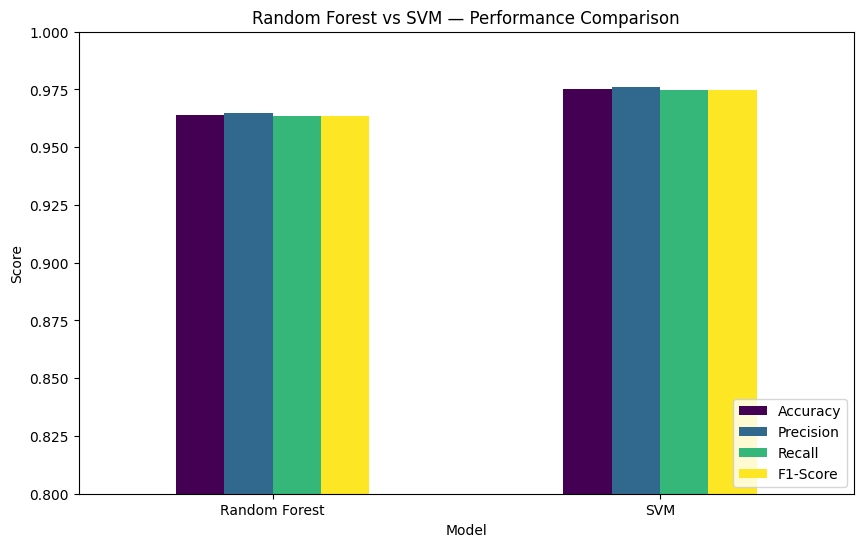

In [18]:
# Direct comparison table
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'SVM'],
    'Accuracy': [accuracy, svm_accuracy],
    'Precision': [precision, svm_precision],
    'Recall': [recall, svm_recall],
    'F1-Score': [f1, svm_f1]
})
print("\nModel Comparison:")
print(comparison_df)

# Visualize the comparison
comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(10, 6), colormap='viridis'
)
plt.title('Random Forest vs SVM — Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.8, 1.0)
plt.legend(loc='lower right')
plt.show()

### Random Forest vs. SVM — Comparison Insights

SVM outperformed Random Forest across every metric, by a consistent margin of roughly 1.1 percentage
points (Accuracy: 97.50% vs. 96.39%; F1-score: 97.48% vs. 96.35%). This consistency across accuracy,
precision, recall, and F1 (rather than SVM winning on one metric and losing on another) suggests a
genuine, if modest, advantage rather than a fluke of this particular train/test split.

This result is plausible given the nature of the data: handwritten digit images are low-dimensional
(64 pixels) and the 10 classes are visually well-separated, conditions where SVM's margin-maximizing
RBF kernel tends to perform very well. Random Forest, while also strong (96.39% accuracy after
extensive tuning across 108 parameter combinations), doesn't have as natural an advantage here since
tree-based axis-aligned splits aren't always the most efficient way to capture smooth, continuous
pixel-intensity patterns the way a kernel-based method can

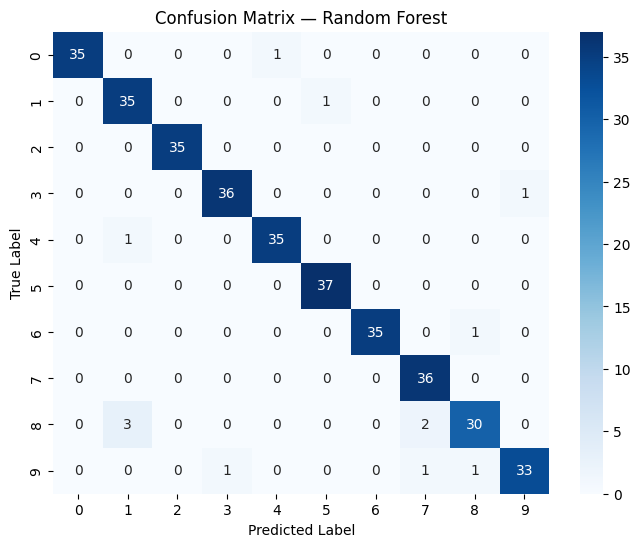

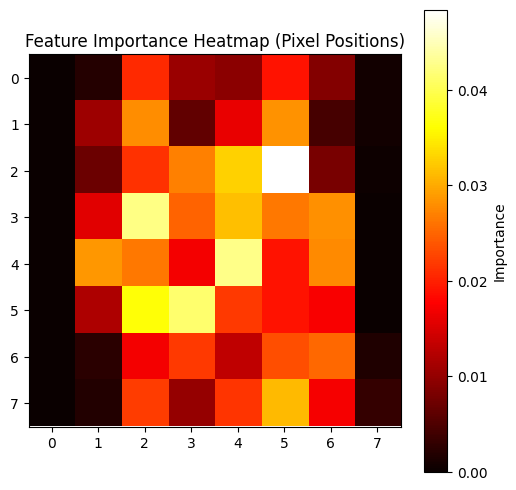

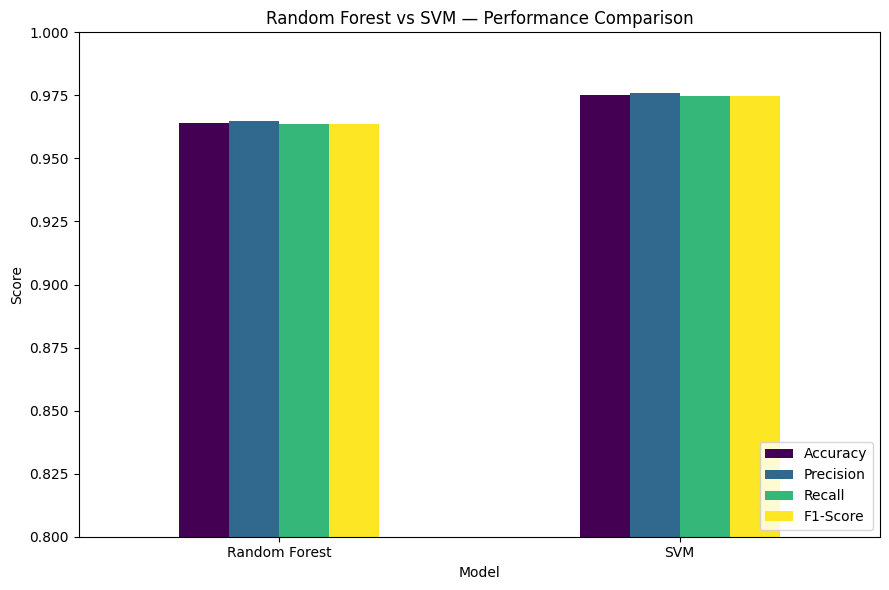

Figures saved.


In [19]:
import os
os.makedirs('figures', exist_ok=True)

# Figure 1: Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: Feature importance heatmap
plt.figure(figsize=(6, 6))
plt.imshow(importances.reshape(8, 8), cmap='hot', interpolation='nearest')
plt.title('Feature Importance Heatmap (Pixel Positions)')
plt.colorbar(label='Importance')
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 3: Model comparison bar chart
comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(9, 6), colormap='viridis'
)
plt.title('Random Forest vs SVM — Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.8, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figures saved")

In [20]:
!git config --global user.name "conslcan"
!git config --global user.email "conslcan@gmail.com"
!git clone https://github.com/conslcan/Wejdan-Assignment2-Git-Colab.git

Cloning into 'Wejdan-Assignment2-Git-Colab'...
remote: Enumerating objects: 88, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 88 (delta 28), reused 63 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (88/88), 3.28 MiB | 19.90 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [21]:
import os
base = '/content/Wejdan-Assignment2-Git-Colab/digits-classification'
os.makedirs(f'{base}/figures', exist_ok=True)
os.makedirs(f'{base}/report', exist_ok=True)
print("Folders created.")

Folders created.


In [22]:
import shutil
for fname in os.listdir('figures'):
    shutil.copy(f'figures/{fname}', f'{base}/figures/{fname}')
print("Figures copied.")

Figures copied.
